In [1]:
from sklearn.datasets import make_classification
from sklearn.ensemble import RandomForestClassifier
from sklearn import tree
from sklearn.tree import DecisionTreeClassifier
from sklearn.inspection import DecisionBoundaryDisplay
from sklearn.model_selection import train_test_split
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
import pandas as pd
df = pd.read_csv("..\..\data\Metadata_features\metadata_features.csv")
df.head()

,img_id,patient_id,lesion_id,gender,skin_cancer_diagnosis,diagnostic,biopsed,mask_components,melanoma_color_count,melanoma_colors,...,worst_score,Polsby-Popper,convexity_score,lesion_red_share,lesion_green_share,lesion_blue_share,lesion_skin_red_diff,lesion_skin_green_diff,lesion_skin_blue_diff,lesion_skin_rgb_distance
0,PAT_684_1303_368.png,PAT_684,1303,MALE,1,BCC,True,2,1,blue_gray,...,0.216200,0.397353,0.966073,0.385627,0.316149,0.298224,-4.110664,-4.335522,-3.519299,6.933958
1,PAT_842_1606_971.png,PAT_842,1606,FEMALE,1,BCC,True,3,1,blue_gray,...,0.416755,0.368211,0.968111,0.347777,0.307446,0.344777,-8.710226,-22.357424,-8.463104,25.443006
2,PAT_113_172_610.png,PAT_113,172,MALE,1,SCC,True,2,2,"red, blue_gray",...,0.273122,0.380454,0.982251,0.446228,0.283676,0.270096,7.774562,-7.024822,-2.797506,10.845182
3,PAT_1633_2855_460.png,PAT_1633,2855,NaN,0,ACK,False,5,0,NaN,...,0.653887,0.276993,0.981541,0.425111,0.309371,0.265518,16.566090,18.314028,26.037217,35.885591
4,PAT_168_262_74.png,PAT_168,262,MALE,1,BCC,True,1,1,blue_gray,...,0.200931,0.754520,0.964321,0.417867,0.292136,0.289997,-12.708808,-19.862190,-18.049245,29.695044


In [13]:
x = df[['lesion_green_share', 'saturation_variance', 'melanoma_color_count',
       'mabrouk_asymmetry_score', 'avg_asymmetry_score', 'worst_score',
       'convexity_score', 'lesion_red_share', 'lesion_skin_green_diff',
       'Polsby-Popper']]
y = df['skin_cancer_diagnosis']

In [14]:
from sklearn.model_selection import train_test_split


dev_x, test_x, dev_y, test_y = train_test_split(
        x, y, stratify=y, random_state=0)

train_x, val_x, train_y, val_y = train_test_split(
        dev_x, dev_y, stratify=dev_y, random_state=0)

In [6]:
x

,melanoma_color_count,hue_variance,saturation_variance,value_variance,mabrouk_asymmetry_score,avg_asymmetry_score,worst_score,Polsby-Popper,convexity_score,lesion_red_share,lesion_green_share,lesion_blue_share,lesion_skin_red_diff,lesion_skin_green_diff,lesion_skin_blue_diff,lesion_skin_rgb_distance
0,1,0.003734,0.014368,0.013598,0,0.181143,0.216200,0.397353,0.966073,0.385627,0.316149,0.298224,-4.110664,-4.335522,-3.519299,6.933958
1,1,0.143109,0.001537,0.003105,0,0.301297,0.416755,0.368211,0.968111,0.347777,0.307446,0.344777,-8.710226,-22.357424,-8.463104,25.443006
2,2,0.002274,0.018044,0.004772,0,0.190298,0.273122,0.380454,0.982251,0.446228,0.283676,0.270096,7.774562,-7.024822,-2.797506,10.845182
3,0,0.001311,0.001702,0.002817,0,0.478766,0.653887,0.276993,0.981541,0.425111,0.309371,0.265518,16.566090,18.314028,26.037217,35.885591
4,1,0.008007,0.015162,0.003787,0,0.157402,0.200931,0.754520,0.964321,0.417867,0.292136,0.289997,-12.708808,-19.862190,-18.049245,29.695044
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2089,0,0.007189,0.000370,0.006851,0,0.208439,0.267667,0.789385,0.974230,0.400132,0.338470,0.261398,-45.803908,-22.214268,-32.459787,60.374742
2090,0,0.001615,0.002899,0.002817,0,0.133728,0.177111,0.879385,0.988129,0.548378,0.242980,0.208642,-1.780611,-9.251593,0.529040,9.436230
2091,0,0.001357,0.004829,0.002076,0,0.120434,0.163072,0.874403,0.990189,0.432611,0.300102,0.267287,-16.706975,-23.504266,-15.990144,32.973599
2092,0,0.017869,0.006313,0.000669,0,0.215483,0.275429,0.739382,0.964640,0.422920,0.269573,0.307507,-4.347811,-39.457351,-17.548900,43.402188


In [15]:
decision_tree = DecisionTreeClassifier(
    max_depth=None,
    random_state=1907,
    
    )
decision_tree.fit(train_x, train_y)

print(f"Mean accuracy: {decision_tree.score(val_x, val_y)}")
print(f"Train accuracy: {decision_tree.score(train_x, train_y)}")

Mean accuracy: 0.6361323155216285
Train accuracy: 1.0


In [16]:
#fig, ax = plt.subplots(2, 3, figsize=(10, 6))
depths = range(1, 9)

for i, d in enumerate(depths):
    decision_tree = DecisionTreeClassifier(max_depth=d, random_state=1907)
    decision_tree.fit(train_x,train_y)

    # plot
    #row, col = i // 3, i % 3
    #DecisionBoundaryDisplay.from_estimator(decision_tree,train_x,alpha=0.5, ax=ax[row, col])
    #ax[row, col].scatter(val_x[:,0],val_x[:,1],c=val_y)
    #ax[row, col].set_title(f"max_depth={d}")
    print(f"max_depth= {d} - Train accuracy: {decision_tree.score(train_x,train_y)} - Val accuracy: {decision_tree.score(val_x,val_y)}")

max_depth= 1 - Train accuracy: 0.6677994902293968 - Val accuracy: 0.6717557251908397
max_depth= 2 - Train accuracy: 0.6839422259983008 - Val accuracy: 0.6819338422391857
max_depth= 3 - Train accuracy: 0.7026338147833475 - Val accuracy: 0.6946564885496184
max_depth= 4 - Train accuracy: 0.7187765505522515 - Val accuracy: 0.6768447837150128
max_depth= 5 - Train accuracy: 0.7408666100254885 - Val accuracy: 0.6793893129770993
max_depth= 6 - Train accuracy: 0.784197111299915 - Val accuracy: 0.6895674300254453
max_depth= 7 - Train accuracy: 0.8275276125743416 - Val accuracy: 0.6819338422391857
max_depth= 8 - Train accuracy: 0.8598130841121495 - Val accuracy: 0.6717557251908397


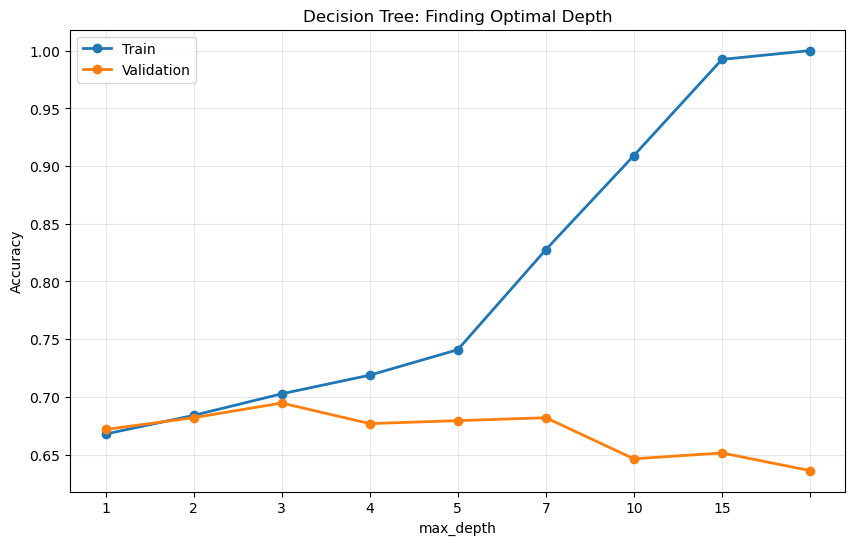

In [17]:
depths = [1, 2, 3, 4, 5, 7, 10, 15, None]
train_accs = []
val_accs = []

for d in depths:
    dt = DecisionTreeClassifier(max_depth=d, random_state=1907)
    dt.fit(train_x, train_y)
    train_accs.append(dt.score(train_x, train_y))
    val_accs.append(dt.score(val_x, val_y))

plt.figure(figsize=(10, 6))
plt.plot(range(len(depths)), train_accs, marker='o', label='Train', linewidth=2)
plt.plot(range(len(depths)), val_accs, marker='o', label='Validation', linewidth=2)
plt.xticks(range(len(depths)), depths)
plt.xlabel('max_depth')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Decision Tree: Finding Optimal Depth')
plt.grid(True, alpha=0.3)
plt.show()

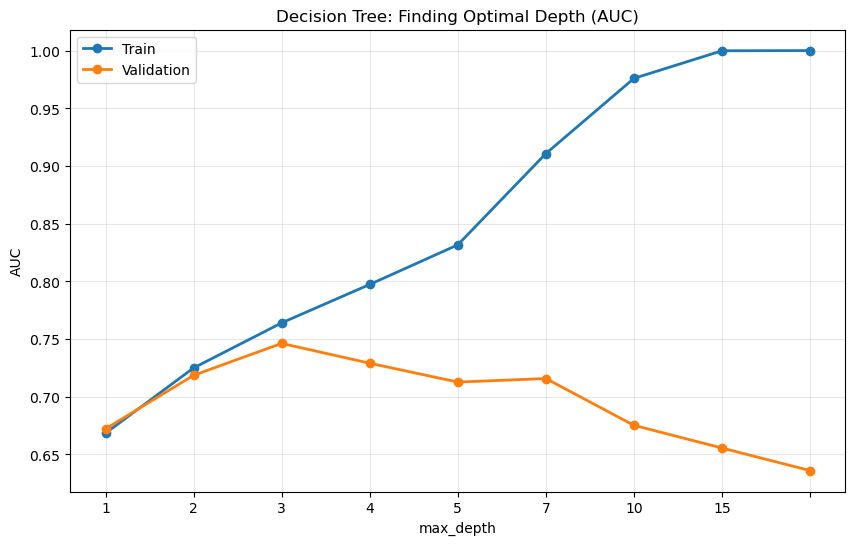

In [18]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import roc_auc_score
import matplotlib.pyplot as plt

depths = [1, 2, 3, 4, 5, 7, 10, 15, None]
train_aucs = []
val_aucs = []


for d in depths:
    dt = DecisionTreeClassifier(max_depth=d, random_state=1907)
    dt.fit(train_x, train_y)

    train_probs = dt.predict_proba(train_x)[:, 1]
    val_probs = dt.predict_proba(val_x)[:, 1]

    train_aucs.append(roc_auc_score(train_y, train_probs))
    val_aucs.append(roc_auc_score(val_y, val_probs))

plt.figure(figsize=(10, 6))
plt.plot(range(len(depths)), train_aucs, marker='o', label='Train', linewidth=2)
plt.plot(range(len(depths)), val_aucs, marker='o', label='Validation', linewidth=2)

plt.xticks(range(len(depths)), depths)
plt.xlabel('max_depth')
plt.ylabel('AUC')
plt.title('Decision Tree: Finding Optimal Depth (AUC)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

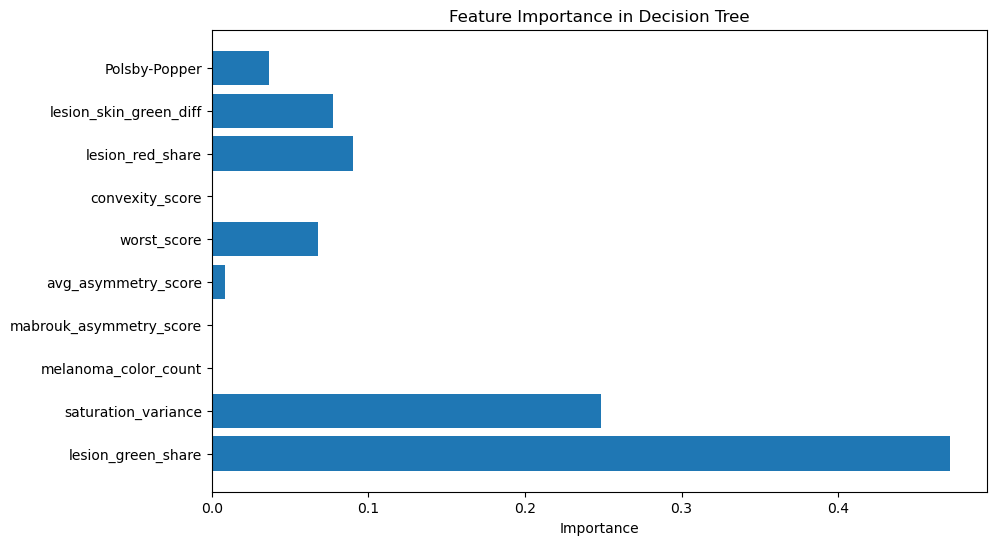

In [20]:
# Train your best model
dt = DecisionTreeClassifier(max_depth=5, random_state=1907)
dt.fit(train_x, train_y)

# See which features are most important
feature_names = ['lesion_green_share', 'saturation_variance', 'melanoma_color_count',
       'mabrouk_asymmetry_score', 'avg_asymmetry_score', 'worst_score',
       'convexity_score', 'lesion_red_share', 'lesion_skin_green_diff',
       'Polsby-Popper']

plt.figure(figsize=(10, 6))
plt.barh(feature_names, dt.feature_importances_)
plt.xlabel('Importance')
plt.title('Feature Importance in Decision Tree')
plt.show()